# Kombinasi 3: Bayesian Quantum Game & Nash Optimizer

Notebook ini merupakan evolusi dari Kombinasi 2, dengan dua pembaruan utama:
1. **Bayesian Quantum Game Analysis**: Menggunakan *Laplace Smoothing* (Dirichlet Prior) untuk menghitung matriks payoff yang lebih stabil terhadap data terbatas.
2. **Game Theory Optimizer (Nash Optimizer)**: Menggantikan optimasi berbasis gradien dengan logika pengambilan keputusan Nash, di mana setiap parameter sirkuit kuantum bertindak sebagai pemain yang mencoba meminimalkan energi Hamiltonian.

In [1]:
# 1. Setup & Imports
import pennylane as qml
from pennylane import numpy as np
import yfinance as yf
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import scipy.linalg as la

print(f"PennyLane version: {qml.__version__}")

PennyLane version: 0.44.0


In [2]:
# 2. Smart Asset Selection (Classical)

def select_top_assets(tickers, period="2y"):
    print(f"Fetching data for: {tickers}...")
    try:
        data = yf.download(tickers, period=period)['Close']
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        
        returns = data.pct_change().dropna()
        
        mean_returns = returns.mean() * 252
        volatility = returns.std() * np.sqrt(252)
        sharpe_ratios = mean_returns / volatility
        
        metrics = pd.DataFrame({
            'Annual Return': mean_returns,
            'Volatility (Risk)': volatility,
            'Sharpe Ratio': sharpe_ratios
        })
        
        print("\n--- Asset Performance Metrics ---")
        print(metrics.sort_values(by='Sharpe Ratio', ascending=False))
        
        top_2 = sharpe_ratios.sort_values(ascending=False).head(2).index.tolist()
        print(f"\nSelected Assets (Top 2 Sharpe): {top_2}")
        
        return top_2, returns[top_2]
        
    except Exception as e:
        print(f"Error in selection: {e}. Using fallback.")
        return ['GC=F', 'SI=F'], pd.DataFrame()

tickers = ['GC=F', 'SI=F', 'BBCA.JK', 'BTC-USD']
selected_tickers, selected_returns = select_top_assets(tickers)

Fetching data for: ['GC=F', 'SI=F', 'BBCA.JK', 'BTC-USD']...


[*********************100%***********************]  4 of 4 completed


--- Asset Performance Metrics ---
         Annual Return  Volatility (Risk)  Sharpe Ratio
Ticker                                                 
GC=F          0.463686           0.204082      2.272058
SI=F          0.584315           0.455568      1.282610
BTC-USD       0.131690           0.464174      0.283709
BBCA.JK      -0.009079           0.253265     -0.035848

Selected Assets (Top 2 Sharpe): ['GC=F', 'SI=F']


In [3]:
# 3. Bayesian Quantum Game Theory Analysis

def analyze_bayesian_quantum_game(returns, asset_a, asset_b, alpha=1.0):
    print(f"\nAnalyzing interaction (Bayesian): {asset_a} vs {asset_b}")
    state_A = (returns[asset_a] < 0).astype(int)
    state_B = (returns[asset_b] < 0).astype(int)

    n_ij = np.zeros((2, 2))
    sum_A = np.zeros((2, 2))
    sum_B = np.zeros((2, 2))

    for i in range(len(returns)):
        a, b = state_A.iloc[i], state_B.iloc[i]
        n_ij[a, b] += 1
        sum_A[a, b] += returns[asset_a].iloc[i]
        sum_B[a, b] += returns[asset_b].iloc[i]

    # Bayesian Update with Laplace Smoothing
    n_posterior = n_ij + alpha
    n_total_posterior = n_posterior.sum()

    prob_matrix = n_posterior / n_total_posterior
    payoff_A = sum_A / n_posterior
    payoff_B = sum_B / n_posterior

    return payoff_A, payoff_B, prob_matrix

def calculate_qmi(probs):
    rho_AB = probs / np.sum(probs)
    rho_A = np.diag([probs[0,0] + probs[0,1], probs[1,0] + probs[1,1]])
    rho_B = np.diag([probs[0,0] + probs[1,0], probs[0,1] + probs[1,1]])

    def vn_entropy(rho):
        ev = la.eigvalsh(rho)
        ev = ev[ev > 1e-12]
        return -np.sum(ev * np.log2(ev))

    return vn_entropy(rho_A) + vn_entropy(rho_B) - vn_entropy(rho_AB)

pA, pB, probs = analyze_bayesian_quantum_game(selected_returns, selected_tickers[0], selected_tickers[1])
qmi = calculate_qmi(probs)
print(f"Quantum Mutual Information (Entanglement): {qmi:.4f}")


Analyzing interaction (Bayesian): GC=F vs SI=F
Quantum Mutual Information (Entanglement): 0.9695


In [4]:
# 4. Hamiltonian Construction

h_A = (pA[0,0] + pA[0,1]) - (pA[1,0] + pA[1,1])
h_B = (pB[0,0] + pB[1,0]) - (pB[0,1] + pB[1,1])
J_AB = qmi * 0.5

print(f"Hamiltonian Params: h_{selected_tickers[0]}={h_A:.4f}, h_{selected_tickers[1]}={h_B:.4f}, J={J_AB:.4f}")

obs = [qml.PauliZ(0), qml.PauliZ(1), qml.PauliZ(0) @ qml.PauliZ(1)]
coeffs = [-h_A, -h_B, -J_AB]
H = qml.Hamiltonian(coeffs, obs)
print("Hamiltonian:\n", H)

Hamiltonian Params: h_GC=F=0.0286, h_SI=F=0.0574, J=0.4847
Hamiltonian:
 -0.02857609404961175 * Z(0) + -0.057357238844906636 * Z(1) + -0.48473666498176693 * (Z(0) @ Z(1))


Running VQE with Nash Optimizer...
Iter 0: Cost = 0.307918
Iter 20: Cost = -0.464778
Iter 40: Cost = -0.569738
Iter 60: Cost = -0.569738
Iter 80: Cost = -0.569738
Final VQE Energy: -0.569738


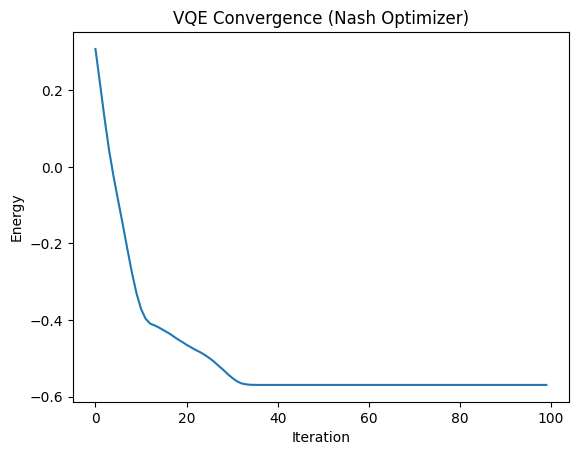

In [8]:
# 5. VQE Optimization (Nash Optimizer)

n_qubits = 2
depth = 2
dev = qml.device("default.qubit", wires=n_qubits)

def hardware_efficient_ansatz(weights, wires, depth):
    for i in wires:
        qml.RZ(weights[0, i, 0], wires=i)
        qml.RX(weights[0, i, 1], wires=i)
        qml.RZ(weights[0, i, 2], wires=i)
    for d in range(depth):
        qml.CNOT(wires=[wires[0], wires[1]])
        for i in wires:
            qml.RZ(weights[d+1, i, 0], wires=i)
            qml.RX(weights[d+1, i, 1], wires=i)
            qml.RZ(weights[d+1, i, 2], wires=i)

@qml.qnode(dev)
def circuit(weights):
    hardware_efficient_ansatz(weights, wires=[0, 1], depth=depth)
    return qml.expval(H)

def game_theory_optimizer_step(cost_fn, current_weights, step_size=0.1):
    new_weights = current_weights.copy()
    for i in range(len(new_weights)):
        # Pemain i mencoba strategi Naik
        weights_plus = new_weights.copy()
        weights_plus[i] += step_size
        cost_plus = cost_fn(weights_plus)

        # Pemain i mencoba strategi Turun
        weights_minus = new_weights.copy()
        weights_minus[i] -= step_size
        cost_minus = cost_fn(weights_minus)

        # Strategi Diam (Current)
        current_cost = cost_fn(new_weights)

        # Pilih yang terbaik (Nash Decision)
        if cost_plus < current_cost and cost_plus < cost_minus:
            new_weights[i] += step_size
        elif cost_minus < current_cost and cost_minus < cost_plus:
            new_weights[i] -= step_size
    return new_weights

param_shape = (depth + 1, n_qubits, 3)
np.random.seed(42)
initial_weights = np.random.random(param_shape) * 2 * np.pi
flat_weights = initial_weights.flatten()

def cost_wrapper(flat_w):
    return circuit(flat_w.reshape(param_shape))

costs = []
print("Running VQE with Nash Optimizer...")
for i in range(100):
    flat_weights = game_theory_optimizer_step(cost_wrapper, flat_weights, step_size=0.05)
    cost = cost_wrapper(flat_weights)
    costs.append(cost)
    if i % 20 == 0: print(f"Iter {i}: Cost = {cost:.6f}")

final_weights = flat_weights.reshape(param_shape)
print(f"Final VQE Energy: {costs[-1]:.6f}")

plt.plot(costs)
plt.title('VQE Convergence (Nash Optimizer)')
plt.ylabel('Energy')
plt.xlabel('Iteration')
plt.show()

In [6]:
# 6. Result & Verification

@qml.qnode(dev)
def get_probs(weights):
    hardware_efficient_ansatz(weights, wires=[0, 1], depth=depth)
    return qml.probs(wires=[0, 1])

probs_vqe = get_probs(final_weights)
states = ["|00> (Both Up)", "|01> (A Up, B Down)", "|10> (A Down, B Up)", "|11> (Both Down)"]

print(f"\n--- Selected Assets: {selected_tickers} ---")
print("Quantum State Probabilities:")
for s, p in zip(states, probs_vqe):
    print(f"{s}: {p:.4f}")

best_state = states[np.argmax(probs_vqe)]
print(f"\nRecommended Strategy (Nash Eq): {best_state}")

# Exact Check
H_mat = qml.matrix(H)
if hasattr(H_mat, "todense"): H_mat = H_mat.todense()
exact_en = la.eigh(H_mat)[0][0]

print(f"\nVerification:")
print(f"VQE (Nash): {costs[-1]:.6f} | Exact: {exact_en:.6f}")


--- Selected Assets: ['GC=F', 'SI=F'] ---
Quantum State Probabilities:
|00> (Both Up): 0.9952
|01> (A Up, B Down): 0.0001
|10> (A Down, B Up): 0.0001
|11> (Both Down): 0.0047

Recommended Strategy (Nash Eq): |00> (Both Up)

Verification:
VQE (Nash): -0.569738 | Exact: -0.570670
